# 🌥️ Ichimoku Cloud Technical Indicator Project

## 🔹 Overview
This project demonstrates how to calculate and visualize the **Ichimoku Kinko Hyo (Ichimoku Cloud)** indicator.  
Developed in Japan by Goichi Hosoda, Ichimoku is a **comprehensive trading system** that provides insights into **trend, momentum, and support/resistance** — all in a single chart.

The Ichimoku system consists of:
- **Tenkan-sen (Conversion Line)** → short-term trend  
- **Kijun-sen (Base Line)** → medium-term trend  
- **Senkou Span A & B** → form the **Kumo (cloud)**, representing dynamic support/resistance  
- **Chikou Span (Lagging Span)** → closing price plotted backward, confirming trend strength  

---

## 🔹 Technical Background

### Components & Formulas
1. **Tenkan-sen (Conversion Line, 9-period)**
\[
Tenkan = \frac{\max(High_{9}) + \min(Low_{9})}{2}
\]

2. **Kijun-sen (Base Line, 26-period)**
\[
Kijun = \frac{\max(High_{26}) + \min(Low_{26})}{2}
\]

3. **Senkou Span A (Leading Span A)**
\[
SpanA = \frac{Tenkan + Kijun}{2} \quad \text{(plotted 26 periods ahead)}
\]

4. **Senkou Span B (Leading Span B, 52-period)**
\[
SpanB = \frac{\max(High_{52}) + \min(Low_{52})}{2} \quad \text{(plotted 26 periods ahead)}
\]

5. **Chikou Span (Lagging Span)**
\[
Chikou = Close \quad \text{(plotted 26 periods behind)}
\]


In [1]:
print("Hello World!")

Hello World!


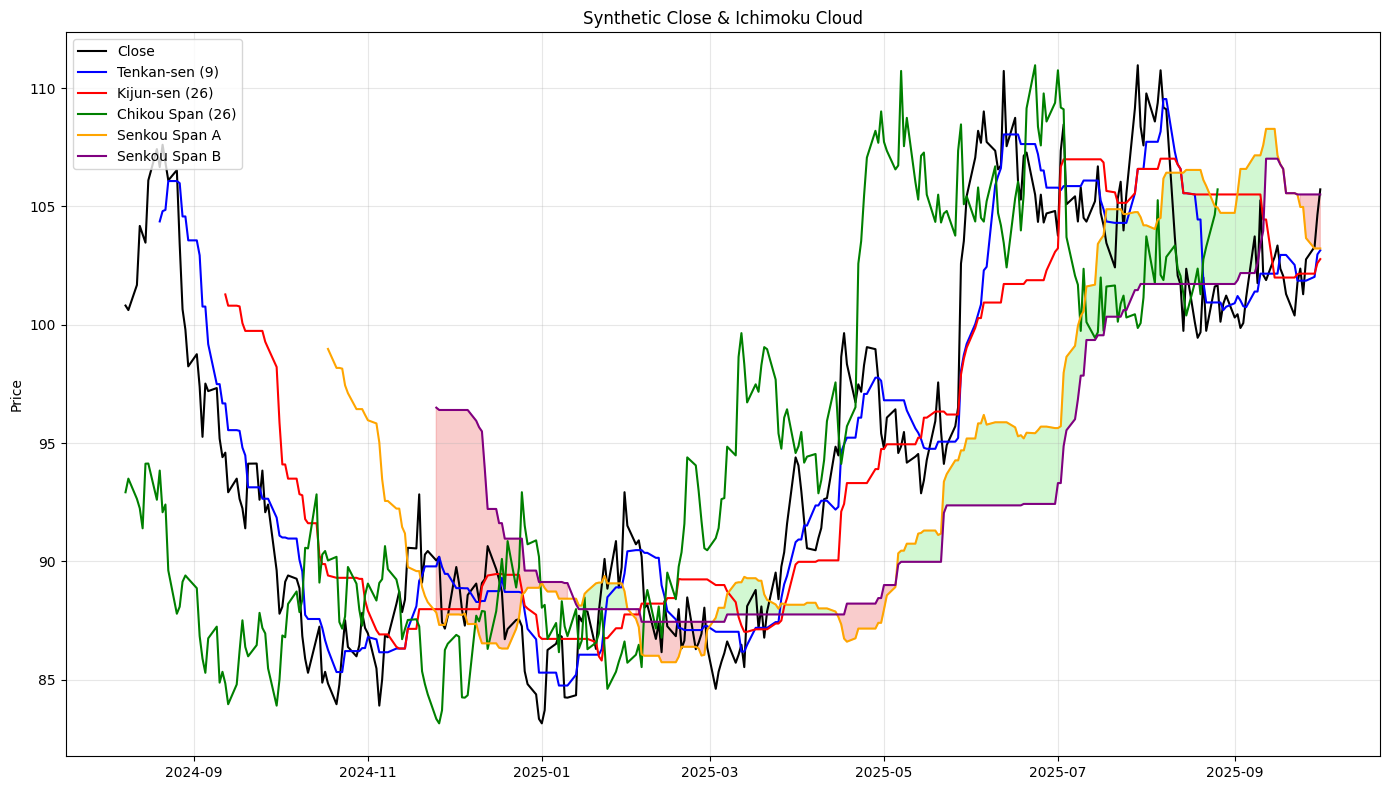

Mode: Synthetic
Rows: 300
Last Close: 105.72
Tenkan-sen: 103.14 | Kijun-sen: 102.77
Senkou Span A: 103.22 | Senkou Span B: 105.51


In [2]:
# ==== Ichimoku Cloud Project ====
# Works with synthetic data by default. Set RUN_MODE="yfinance" for real prices.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------- Config --------
RUN_MODE   = "synthetic"   # "synthetic" or "yfinance"
TICKER     = "AAPL"        # only used if RUN_MODE="yfinance"
PERIOD     = "1y"
INTERVAL   = "1d"

TENKAN = 9     # Conversion Line
KIJUN  = 26    # Base Line
SENKOU = 52    # Leading Span B
SHIFT  = 26    # forward shift for cloud
# -------------------------

# 1) Load Data
if RUN_MODE == "yfinance":
    try:
        import yfinance as yf
        df = yf.download(TICKER, period=PERIOD, interval=INTERVAL, auto_adjust=True, progress=False)
        if df is None or df.empty:
            raise RuntimeError("No data returned.")
        high = pd.to_numeric(df["High"], errors="coerce")
        low  = pd.to_numeric(df["Low"], errors="coerce")
        close= pd.to_numeric(df["Close"], errors="coerce")
        title = f"{TICKER} Close & Ichimoku Cloud"
    except Exception as e:
        print("Falling back to synthetic data because:", e)
        RUN_MODE = "synthetic"

if RUN_MODE == "synthetic":
    np.random.seed(42)
    n = 300
    dates = pd.bdate_range(end=pd.Timestamp.today().normalize(), periods=n)
    mu, sigma, dt = 0.10, 0.25, 1/252
    z = np.random.normal(size=n)
    log_ret = (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*z
    price = 100*np.exp(np.cumsum(log_ret))
    close = pd.Series(price, index=dates, name="Close")
    # make synthetic high/low
    high = close * (1 + np.random.uniform(0.001, 0.02, size=n))
    low  = close * (1 - np.random.uniform(0.001, 0.02, size=n))
    title = "Synthetic Close & Ichimoku Cloud"

# 2) Compute Ichimoku components
tenkan_sen = (high.rolling(TENKAN).max() + low.rolling(TENKAN).min()) / 2
kijun_sen  = (high.rolling(KIJUN).max() + low.rolling(KIJUN).min()) / 2
senkou_a   = ((tenkan_sen + kijun_sen) / 2).shift(SHIFT)
senkou_b   = ((high.rolling(SENKOU).max() + low.rolling(SENKOU).min()) / 2).shift(SHIFT)
chikou_span= close.shift(-SHIFT)  # lagging close

# 3) Plot
fig, ax = plt.subplots(figsize=(14,8))

# Price
ax.plot(close.index, close, label="Close", color="black")

# Ichimoku lines
ax.plot(tenkan_sen.index, tenkan_sen, label=f"Tenkan-sen ({TENKAN})", color="blue")
ax.plot(kijun_sen.index, kijun_sen, label=f"Kijun-sen ({KIJUN})", color="red")
ax.plot(chikou_span.index, chikou_span, label=f"Chikou Span ({SHIFT})", color="green")

# Cloud
ax.plot(senkou_a.index, senkou_a, label="Senkou Span A", color="orange")
ax.plot(senkou_b.index, senkou_b, label="Senkou Span B", color="purple")
ax.fill_between(senkou_a.index, senkou_a, senkou_b,
                where=senkou_a>=senkou_b, color="lightgreen", alpha=0.4)
ax.fill_between(senkou_a.index, senkou_a, senkou_b,
                where=senkou_a<senkou_b, color="lightcoral", alpha=0.4)

ax.set_title(title)
ax.set_ylabel("Price")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

# 4) Summary
print("Mode:", "Real (yfinance)" if RUN_MODE=="yfinance" else "Synthetic")
print("Rows:", len(close))
print("Last Close:", round(close.iloc[-1],2))
print(f"Tenkan-sen: {round(tenkan_sen.iloc[-1],2)} | Kijun-sen: {round(kijun_sen.iloc[-1],2)}")
print(f"Senkou Span A: {round(senkou_a.dropna().iloc[-1],2)} | Senkou Span B: {round(senkou_b.dropna().iloc[-1],2)}")
